<h1>EDA & Preprocessing Code</h1>

In [ ]:
import pandas as pd

# Load your dataset
df = pd.read_csv("Cleaned_NAFLD_Dataset.csv")

# Function to derive NAFLD label
def derive_nafld_label(row):
    bmi = row['BMXBMI']
    waist = row['BMXWAIST']
    chol = row['LBXTC']
    hdl = row['LBDHDD']
    gender = row['RIAGENDR']
    
    # gender-based thresholds
    waist_cutoff = 102 if gender == "Male" else 88
    hdl_cutoff = 40 if gender == "Male" else 50
    
    if (bmi >= 30) and (waist >= waist_cutoff) and (chol > 200 or hdl < hdl_cutoff):
        return 1  # NAFLD Positive
    else:
        return 0  # NAFLD Negative

# Apply function
df['NAFLD_Label'] = df.apply(derive_nafld_label, axis=1)

# Check distribution of classes
print(df['NAFLD_Label'].value_counts())


NAFLD_Label
0    38184
1    10014
Name: count, dtype: int64


Dataset Shape: (48198, 13)

Data Types:
 RIDAGEYR              float64
RIAGENDR               object
RIDRETH1               object
BMXBMI                float64
BMXWAIST              float64
BMXWT                 float64
BMXHT                 float64
BPXSY1                float64
BPXDI1                float64
LBXTC                 float64
LBDHDD                float64
Waist_Height_Ratio    float64
NAFLD_Label             int64
dtype: object

Missing Values:
 RIDAGEYR              0
RIAGENDR              0
RIDRETH1              0
BMXBMI                0
BMXWAIST              0
BMXWT                 0
BMXHT                 0
BPXSY1                0
BPXDI1                0
LBXTC                 0
LBDHDD                0
Waist_Height_Ratio    0
NAFLD_Label           0
dtype: int64


C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\1330608715.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="NAFLD_Label", data=df, palette="Set2")


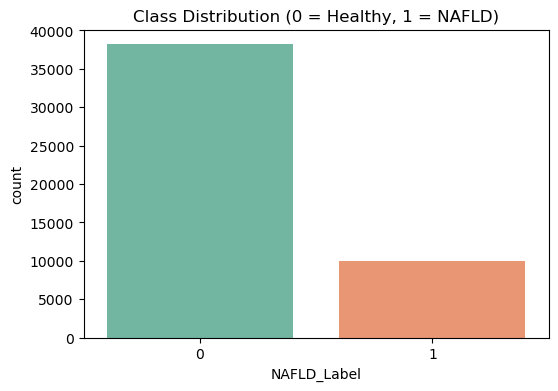

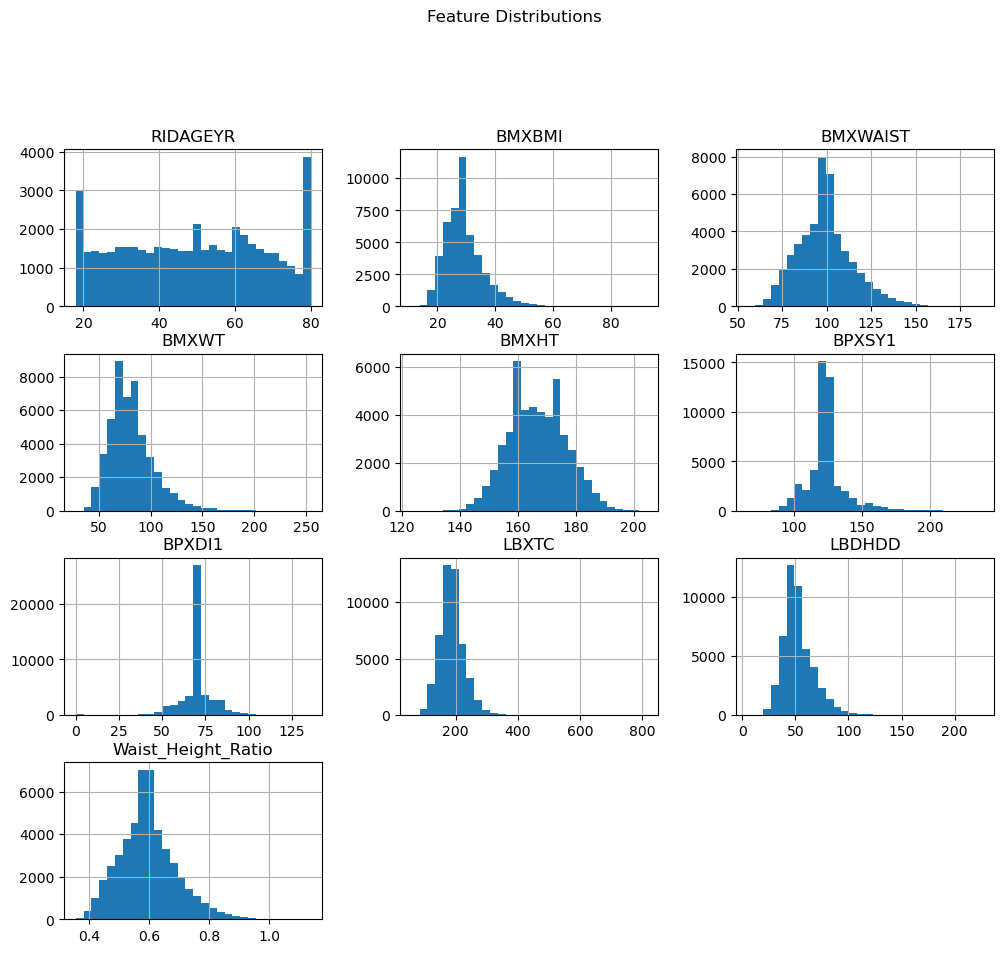

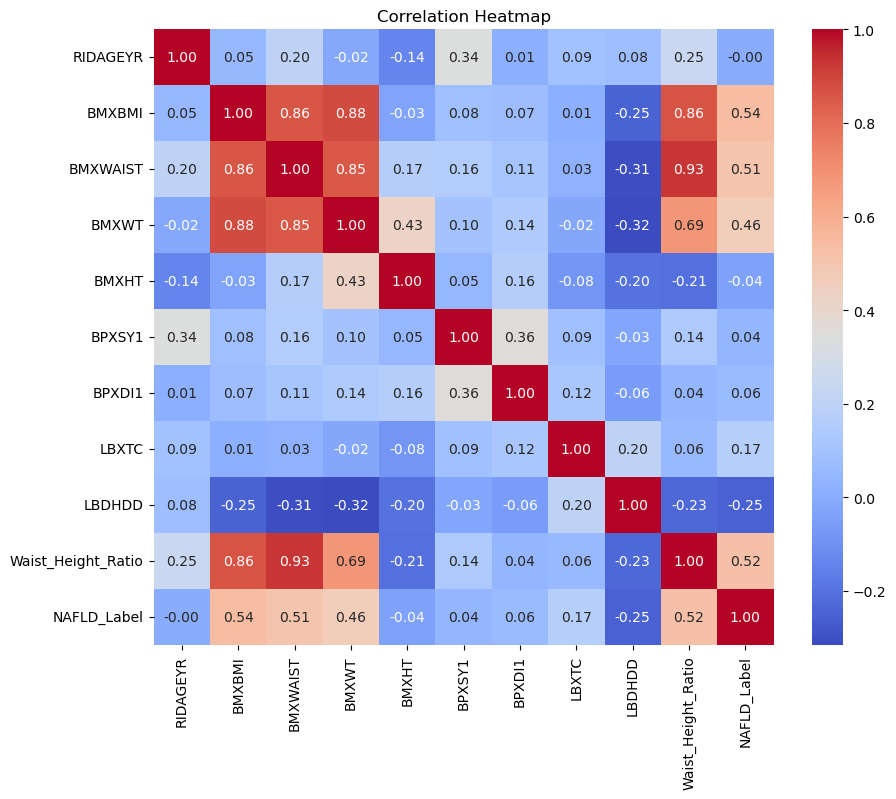

C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\1330608715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NAFLD_Label", y=col, data=df, palette="Set3")
C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\1330608715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NAFLD_Label", y=col, data=df, palette="Set3")
C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\1330608715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="NAFLD_Label", y=col, data=df, palette="Set3")
C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\1330608715.py:49: Fu

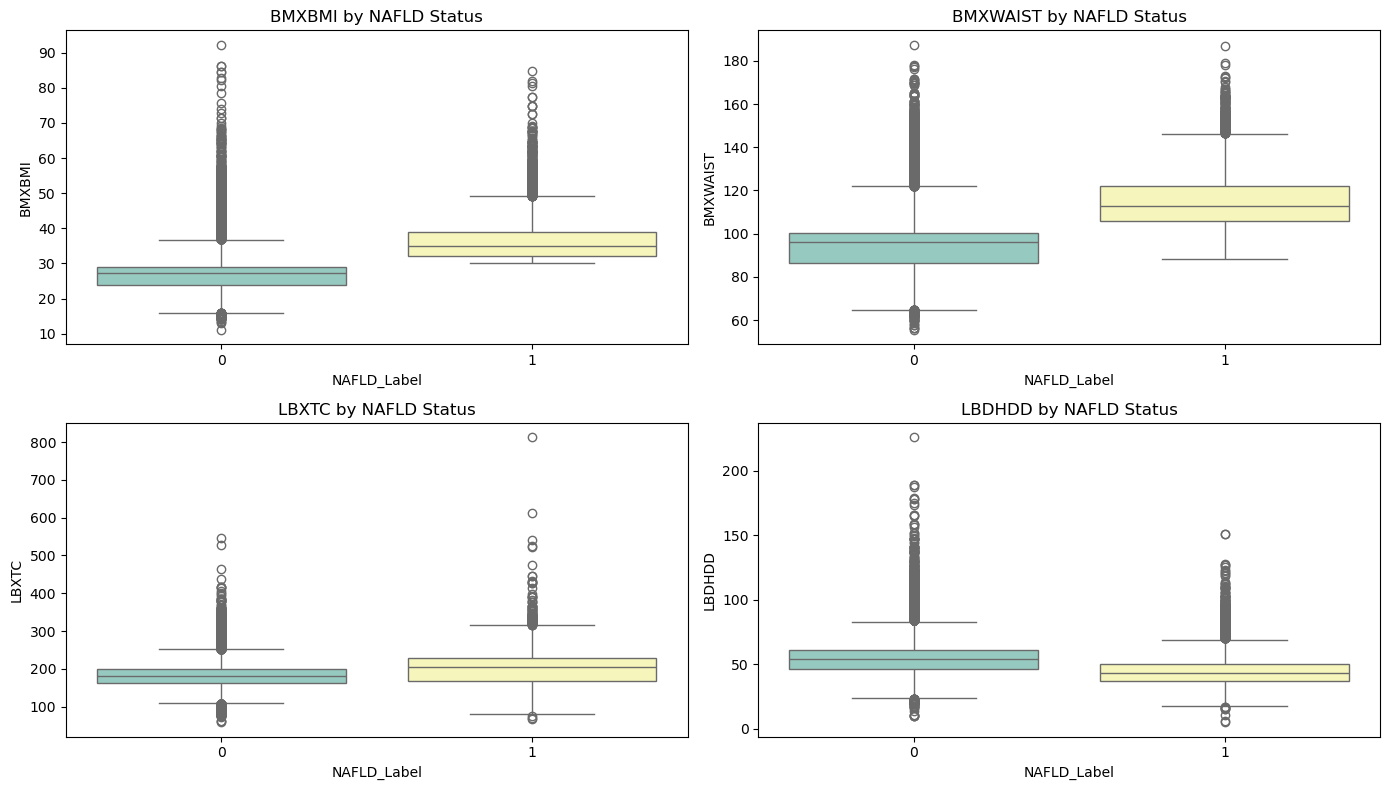

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure NAFLD_Label exists
if 'NAFLD_Label' not in df.columns:
    def derive_nafld_label(row):
        bmi = row['BMXBMI']
        waist = row['BMXWAIST']
        chol = row['LBXTC']
        hdl = row['LBDHDD']
        gender = row['RIAGENDR']
        waist_cutoff = 102 if gender == "Male" else 88
        hdl_cutoff = 40 if gender == "Male" else 50
        if (bmi >= 30) and (waist >= waist_cutoff) and (chol > 200 or hdl < hdl_cutoff):
            return 1
        else:
            return 0
    df['NAFLD_Label'] = df.apply(derive_nafld_label, axis=1)

# ---- Step 1: Quick Overview ----
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# ---- Step 2: Class Distribution ----
plt.figure(figsize=(6,4))
sns.countplot(x="NAFLD_Label", data=df, palette="Set2")
plt.title("Class Distribution (0 = Healthy, 1 = NAFLD)")
plt.show()

# ---- Step 3: Feature Distributions ----
numeric_cols = ['RIDAGEYR','BMXBMI','BMXWAIST','BMXWT','BMXHT','BPXSY1','BPXDI1','LBXTC','LBDHDD','Waist_Height_Ratio']

df[numeric_cols].hist(figsize=(12,10), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

# ---- Step 4: Correlation Heatmap ----
plt.figure(figsize=(10,8))
corr = df[numeric_cols + ['NAFLD_Label']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ---- Step 5: Boxplots (Risk Factors by Label) ----
plt.figure(figsize=(14,8))
for i, col in enumerate(['BMXBMI','BMXWAIST','LBXTC','LBDHDD']):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="NAFLD_Label", y=col, data=df, palette="Set3")
    plt.title(f"{col} by NAFLD Status")
plt.tight_layout()
plt.show()


<h1>Feature Engineering & Imbalance Handling</h1>

Note: you may need to restart the kernel to use updated packages.
Categorical Columns Encoded ✅
Features Standardized ✅


C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\2597870869.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="Set2")


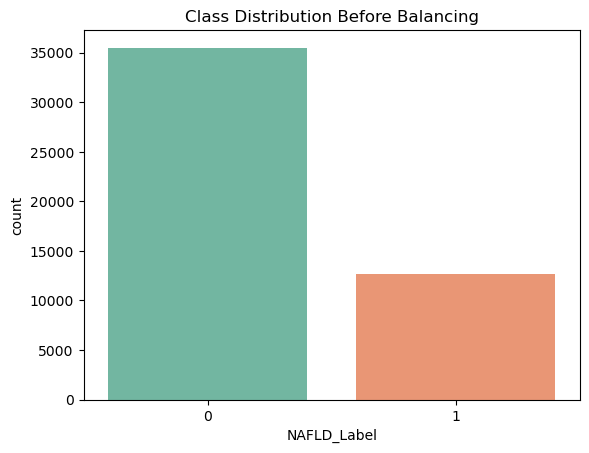

C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\2597870869.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_resampled, palette="Set1")


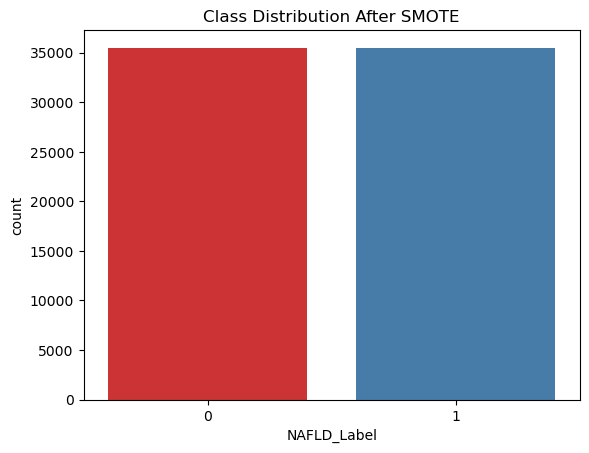

Imbalance handled using SMOTE ✅


C:\Users\WCC\AppData\Local\Temp\ipykernel_7544\2597870869.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


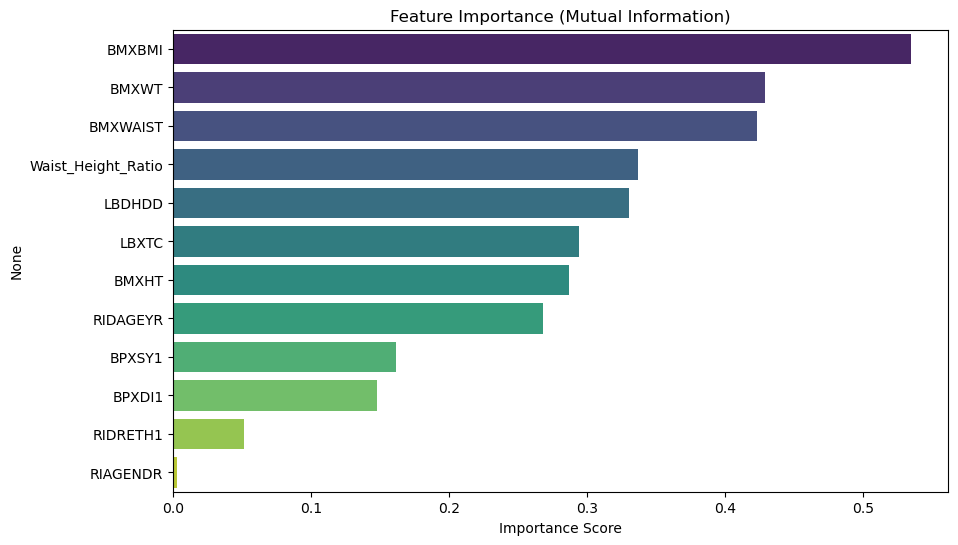

In [ ]:
%pip install imblearn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

# Load dataset
df = pd.read_csv("Cleaned_NAFLD_Dataset.csv")

# Derive NAFLD_Label if not present
if 'NAFLD_Label' not in df.columns:
    def derive_nafld_label(row):
        bmi = row['BMXBMI']
        waist = row['BMXWAIST']
        chol = row['LBXTC']
        hdl = row['LBDHDD']
        gender = row['RIAGENDR']
        waist_cutoff = 102 if gender == 1 else 88  # 1: Male, 0: Female (after encoding)
        hdl_cutoff = 40 if gender == 1 else 50
        if (bmi >= 30) and (waist >= waist_cutoff) and (chol > 200 or hdl < hdl_cutoff):
            return 1
        else:
            return 0
    df['NAFLD_Label'] = df.apply(derive_nafld_label, axis=1)

# ---- Step 1: Encode Categorical Variables ----
categorical_cols = ['RIAGENDR', 'RIDRETH1']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical Columns Encoded ✅")

# ---- Step 2: Feature Scaling ----
features = ['RIDAGEYR','RIAGENDR','RIDRETH1','BMXBMI','BMXWAIST','BMXWT','BMXHT',
            'BPXSY1','BPXDI1','LBXTC','LBDHDD','Waist_Height_Ratio']

X = df[features]
y = df['NAFLD_Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Standardized ✅")

# ---- Step 3: Check Class Balance ----
sns.countplot(x=y, palette="Set2")
plt.title("Class Distribution Before Balancing")
plt.show()

# ---- Step 4: Handle Imbalance with SMOTE ----
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

sns.countplot(x=y_resampled, palette="Set1")
plt.title("Class Distribution After SMOTE")
plt.show()

print("Imbalance handled using SMOTE ✅")

# ---- Step 5: Feature Importance (Mutual Information) ----
mi = mutual_info_classif(X_resampled, y_resampled, random_state=42)
mi_series = pd.Series(mi, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Feature Importance (Mutual Information)")
plt.xlabel("Importance Score")
plt.show()


<h1>Model Training & Evaluation</h1>

c:\Users\WCC\.conda\envs\myenv\lib\site-packages\xgboost\training.py:183: UserWarning: [11:22:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                     Accuracy  Precision    Recall  F1-Score   ROC-AUC
Random Forest        0.999366   0.999859  0.998873  0.999366  0.999993
XGBoost              0.997394   0.997745  0.997042  0.997393  0.999978
SVM                  0.971408   0.956368  0.987887  0.971872  0.996417
Logistic Regression  0.895845   0.890618  0.902535  0.896537  0.949248


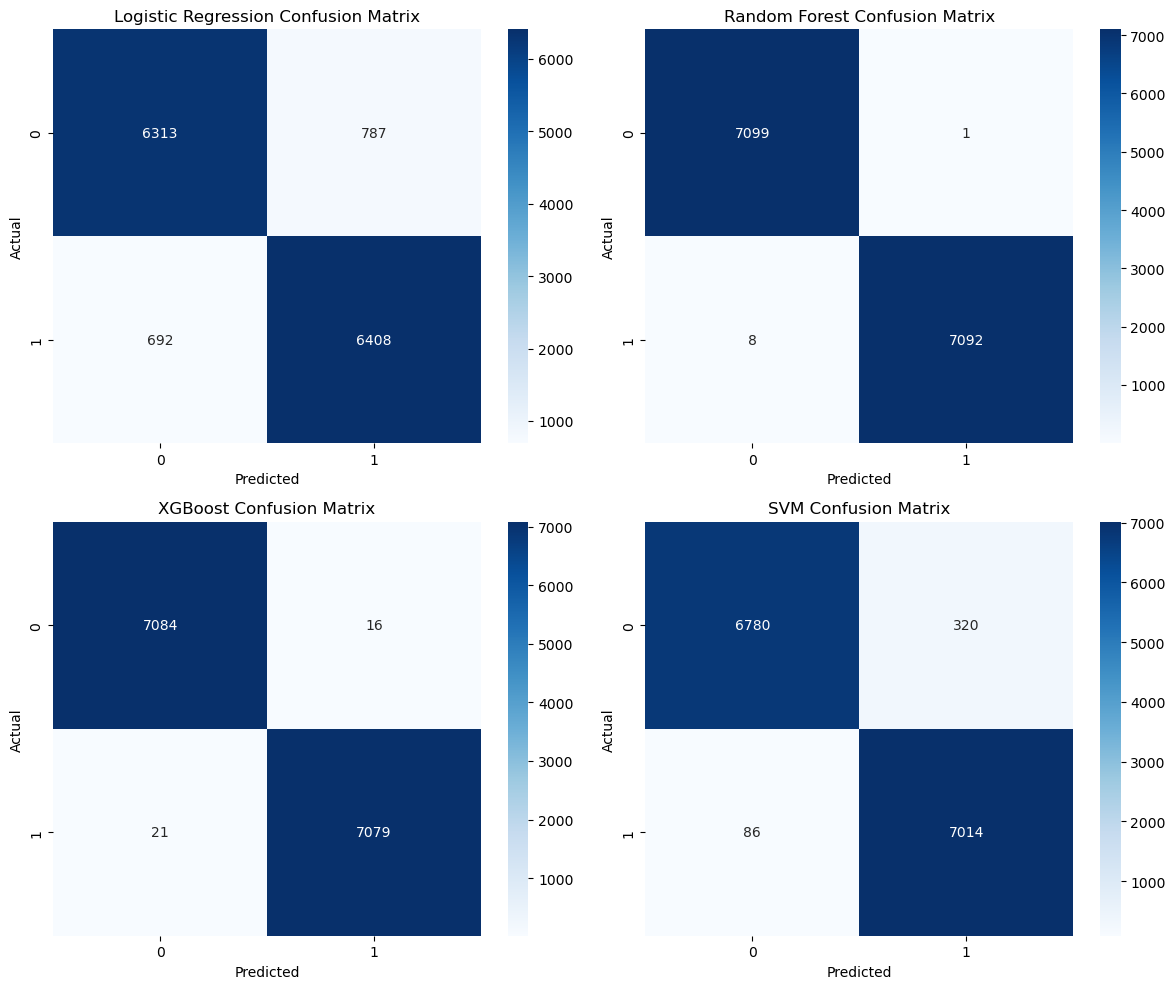

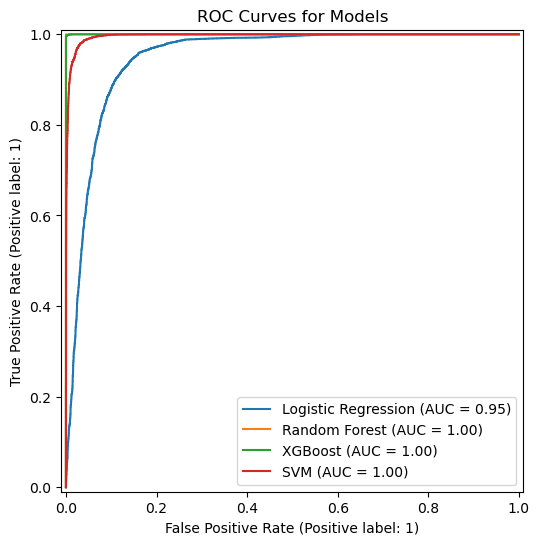

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


# X_resampled, y_resampled (balanced dataset)

# ---- Step 1: Train-Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# ---- Step 2: Initialize Models ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

# ---- Step 3: Train & Evaluate ----
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        "Accuracy": report['accuracy'],
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-Score": report['1']['f1-score'],
        "ROC-AUC": auc
    }

# ---- Step 4: Results Table ----
results_df = pd.DataFrame(results).T.sort_values(by="ROC-AUC", ascending=False)
print(results_df)

# ---- Step 5: Confusion Matrices ----
fig, axes = plt.subplots(2, 2, figsize=(12,10))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ---- Step 6: ROC Curves ----
plt.figure(figsize=(8,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title("ROC Curves for Models")
plt.show()


<h1>Part A — Save the Best Model + Preprocessors</h1>

In [ ]:
import pickle
import numpy as np

# 1) Pick the best model by ROC-AUC (from Day 3 results_df)
best_name = results_df.index[0]
best_model = models[best_name]
print("Best model:", best_name)

# 2) Persist artifacts: model, scaler, encoders, feature list
artifacts = {
    "model_name": best_name,
    "model": best_model,
    "scaler": scaler,                      # from Day 2
    "label_encoders": label_encoders,      # from Day 2: dict for RIAGENDR, RIDRETH1
    "features": features                   # from Day 2
}

with open("nafld_artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Saved -> nafld_artifacts.pkl")


Best model: Random Forest
Saved -> nafld_artifacts.pkl


<h1>Part B — Explainability with SHAP</h1>

<h3>Install & import</h3>

In [ ]:
# In a notebook cell or terminal:
# pip install shap

import shap
import numpy as np
import matplotlib.pyplot as plt


<h3>Load artifacts and pick explainer</h3>

In [ ]:
import pickle

with open("nafld_artifacts.pkl", "rb") as f:
    bundle = pickle.load(f)

best_name = bundle["model_name"]
model = bundle["model"]
scaler = bundle["scaler"]
label_encoders = bundle["label_encoders"]
features = bundle["features"]

print("Loaded best model:", best_name)


Loaded best model: Random Forest


<h3>Global importance (what matters most overall)</h3>

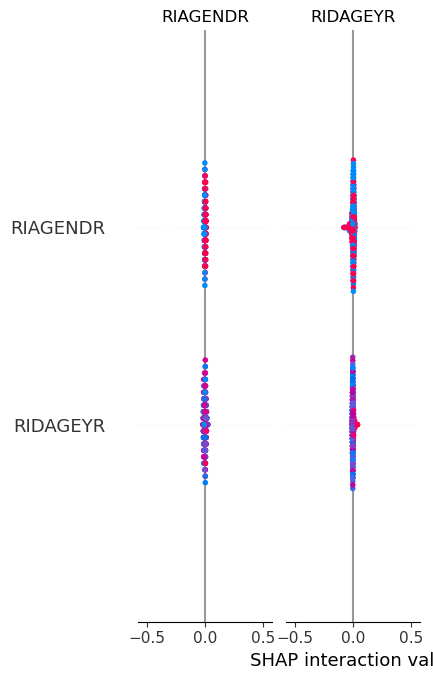

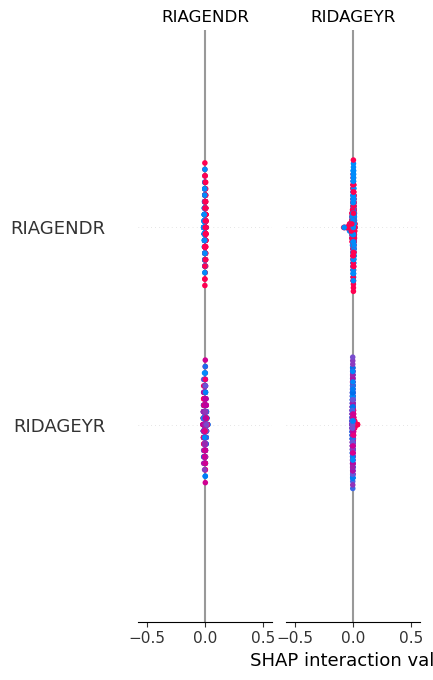

In [ ]:
# Pick a manageable sample for speed
sample_idx = np.random.choice(X_test.shape[0], size=min(400, X_test.shape[0]), replace=False)
X_sample = X_test[sample_idx]

# Define SHAP explainer for RandomForest
explainer = shap.TreeExplainer(model)

# Define is_tree based on model type
is_tree = isinstance(model, (RandomForestClassifier,))

if is_tree:
    shap_values = explainer.shap_values(X_sample)   # returns [neg_class, pos_class] for tree models
    sv_pos = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    shap_values = explainer.shap_values(X_sample)   # KernelExplainer returns 2D for binary if predict_proba
    sv_pos = shap_values

# Summary (beeswarm)
shap.summary_plot(sv_pos, X_sample, feature_names=features, show=True)

# Bar plot variant
shap.summary_plot(sv_pos, X_sample, feature_names=features, plot_type="bar", show=True)


<h1>Part C — Streamlit Mini App (Clinician-friendly)</h1>

<h1>Install Streamlit</h1>

In [ ]:
%pip install streamlit
%pip install --force-reinstall pyzmq



  Using cached pyzmq-27.1.0-cp310-cp310-win_amd64.whl.metadata (6.0 kB)
Using cached pyzmq-27.1.0-cp310-cp310-win_amd64.whl (632 kB)
  Attempting uninstall: pyzmq
    Found existing installation: pyzmq 27.1.0
    Uninstalling pyzmq-27.1.0:
      Successfully uninstalled pyzmq-27.1.0
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.


In [ ]:
import pickle
import numpy as np
import streamlit as st

# ---------- Load artifacts ----------
with open("nafld_artifacts.pkl", "rb") as f:
    bundle = pickle.load(f)

model_name = bundle["model_name"]
model = bundle["model"]
scaler = bundle["scaler"]
label_encoders = bundle["label_encoders"]  # {'RIAGENDR': LabelEncoder, 'RIDRETH1': LabelEncoder}
features = bundle["features"]

st.set_page_config(page_title="NAFLD Risk Predictor", layout="centered")
st.title("🩺 NAFLD Risk Predictor")
st.caption(f"Model: {model_name}")

# ---------- UI Inputs ----------
col1, col2 = st.columns(2)
with col1:
    RIDAGEYR = st.number_input("Age (years)", min_value=18, max_value=90, value=45)
    RIAGENDR = st.selectbox("Gender", options=label_encoders['RIAGENDR'].classes_.tolist())
    RIDRETH1 = st.selectbox("Ethnicity", options=label_encoders['RIDRETH1'].classes_.tolist())
    BMXHT = st.number_input("Height (cm)", min_value=120.0, max_value=210.0, value=170.0, step=0.1)
    BMXWT = st.number_input("Weight (kg)", min_value=35.0, max_value=180.0, value=78.0, step=0.1)

with col2:
    BMXBMI = st.number_input("BMI", min_value=15.0, max_value=60.0, value=27.0, step=0.1)
    BMXWAIST = st.number_input("Waist Circumference (cm)", min_value=50.0, max_value=170.0, value=100.0, step=0.1)
    BPXSY1 = st.number_input("Systolic BP", min_value=80.0, max_value=220.0, value=125.0, step=1.0)
    BPXDI1 = st.number_input("Diastolic BP", min_value=40.0, max_value=140.0, value=80.0, step=1.0)
    LBXTC = st.number_input("Total Cholesterol (mg/dL)", min_value=80.0, max_value=400.0, value=200.0, step=1.0)
    LBDHDD = st.number_input("HDL (mg/dL)", min_value=10.0, max_value=120.0, value=45.0, step=1.0)

# compute Waist_Height_Ratio (cm/cm)
Waist_Height_Ratio = BMXWAIST / BMXHT if BMXHT else 0.0

st.write(f"**Waist-Height Ratio:** {Waist_Height_Ratio:.3f}")

# ---------- Preprocess to model input ----------
# encode cats
RIAGENDR_enc = label_encoders['RIAGENDR'].transform([RIAGENDR])[0] if RIAGENDR in label_encoders['RIAGENDR'].classes_ else 0
RIDRETH1_enc = label_encoders['RIDRETH1'].transform([RIDRETH1])[0] if RIDRETH1 in label_encoders['RIDRETH1'].classes_ else 0

# strict ordering as used in training
row = {
    'RIDAGEYR': RIDAGEYR,
    'RIAGENDR': RIAGENDR_enc,
    'RIDRETH1': RIDRETH1_enc,
    'BMXBMI': BMXBMI,
    'BMXWAIST': BMXWAIST,
    'BMXWT': BMXWT,
    'BMXHT': BMXHT,
    'BPXSY1': BPXSY1,
    'BPXDI1': BPXDI1,
    'LBXTC': LBXTC,
    'LBDHDD': LBDHDD,
    'Waist_Height_Ratio': Waist_Height_Ratio
}

# reorder to features list
x = np.array([[row[f] for f in features]], dtype=float)
x_scaled = scaler.transform(x)

# ---------- Predict ----------
proba = model.predict_proba(x_scaled)[0,1]
pred = int(proba >= 0.5)

st.markdown("---")
st.subheader("Prediction")
st.metric("NAFLD Risk Probability", f"{proba:.2%}")
st.write("**Predicted Class:**", "1 (At Risk)" if pred == 1 else "0 (Low Risk)")

# ---------- Friendly guidance (not medical advice) ----------
st.info(
    "This tool is for educational purposes only and **not** medical advice. "
    "Discuss results with a healthcare professional."
)

# OPTIONAL: Simple risk factors echo
risk_factors = []
if BMXBMI >= 30: risk_factors.append("High BMI (≥30)")
if (RIAGENDR == 'Male' and BMXWAIST >= 102) or (RIAGENDR != 'Male' and BMXWAIST >= 88):
    risk_factors.append("Abdominal obesity (waist)")
if LBXTC > 200: risk_factors.append("High total cholesterol")
if (RIAGENDR == 'Male' and LBDHDD < 40) or (RIAGENDR != 'Male' and LBDHDD < 50):
    risk_factors.append("Low HDL")

if risk_factors:
    st.markdown("**Contributing risk indicators (heuristic):**")
    for rf in risk_factors:
        st.write(f"- {rf}")


2025-09-17 11:27:42.448 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-17 11:27:42.448 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-17 11:27:43.582 
  command:

    streamlit run c:\Users\WCC\.conda\envs\myenv\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-09-17 11:27:43.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-17 11:27:43.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-17 11:27:43.582 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-09-17 11:27:43.598 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored whe